In [1]:
import pandas as pd
from datetime import datetime, timedelta
import time
import os
import json
import matplotlib.pyplot as plt
import pandas_ta as ta
import numpy as np
import schedule
from tvDatafeed import TvDatafeed, Interval
import re
import logging

# Data Processing Pipeline
Process and analyze data saved in the data folder

In [3]:
class DataProcessor:
    def __init__(self, base_path='data'):
        """Initialize the data processor with base path for files"""
        self.base_path = base_path
        self.last_processed = {
            'H1': None,
            'M5': None
        }
        # Create data directory if it doesn't exist
        os.makedirs(base_path, exist_ok=True)

    def is_candle_complete(self, row, timeframe):
        """Check if a candle is complete based on its timestamp"""
        current_time = pd.Timestamp.now(tz='UTC')
        candle_time = pd.to_datetime(row['datetime']).tz_localize('UTC')

        if timeframe == 'H1':
            next_candle = candle_time + pd.Timedelta(hours=1)
        elif timeframe == 'M5':
            next_candle = candle_time + pd.Timedelta(minutes=5)

        return current_time >= next_candle

    def clean_data(self, df, symbol):
        """Clean and standardize the dataframe"""
        df = df.copy()

        # Ensure datetime is properly formatted
        df['datetime'] = pd.to_datetime(df['datetime'])

        # Standardize column names
        column_mapping = {
            'c': 'close',
            'o': 'open',
            'h': 'high',
            'l': 'low',
            'v': 'volume'
        }

        for old, new in column_mapping.items():
            if old in df.columns and new not in df.columns:
                df[new] = df[old]

        # Add symbol if not present
        if 'symbol' not in df.columns:
            df['symbol'] = symbol

        # Remove any duplicate timestamps
        df = df.drop_duplicates(subset=['datetime'])

        # Sort by datetime
        df = df.sort_values('datetime')

        return df

    def process_new_data(self, timeframe, symbol='EURUSD'):
        """Process new data from CSV files when complete candles are available"""
        file_path = f'{timeframe}.csv'
        cleaned_file_path = f'{timeframe}_cleaned.csv'

        if not os.path.exists(file_path):
            print(f"No data file found for {timeframe}")
            return None

        # Read the raw data
        df = pd.read_csv(file_path)
        
        # Filter for complete candles only
        complete_mask = df.apply(lambda row: self.is_candle_complete(row, timeframe), axis=1)
        complete_df = df[complete_mask]

        if complete_df.empty:
            print(f"No complete candles found for {timeframe}")
            return None

        # Get last processed timestamp
        last_processed = self.last_processed[timeframe]

        if last_processed:
            # Only process new data since last processing
            new_data = complete_df[pd.to_datetime(complete_df['datetime']) > last_processed]
            if new_data.empty:
                print(f"No new complete candles for {timeframe}")
                return None
        else:
            new_data = complete_df

        # Clean the new data
        cleaned_data = self.clean_data(new_data, symbol)

        # Update or create the cleaned file
        if os.path.exists(cleaned_file_path):
            existing_cleaned = pd.read_csv(cleaned_file_path)
            existing_cleaned['datetime'] = pd.to_datetime(existing_cleaned['datetime'])
            # Combine existing and new data, removing any duplicates
            combined = pd.concat([existing_cleaned, cleaned_data])
            combined = combined.drop_duplicates(subset=['datetime']).sort_values('datetime')
            combined.to_csv(cleaned_file_path, index=False)
        else:
            cleaned_data.to_csv(cleaned_file_path, index=False)

        # Update last processed timestamp
        self.last_processed[timeframe] = pd.to_datetime(cleaned_data['datetime']).max()

        return cleaned_data

    def get_latest_data(self):
        """Process new data for all timeframes and return the latest clean data"""
        results = {}
        for timeframe in ['H1', 'M5']:
            cleaned_data = self.process_new_data(timeframe)
            if cleaned_data is not None:
                print(f"Processed {len(cleaned_data)} new candles for {timeframe}")
                results[timeframe] = cleaned_data
        return results

    def load_data(self, timeframe):
        """Load data from CSV files"""
        file_path = os.path.join(self.base_path, f'{timeframe}.csv')
        if not os.path.exists(file_path):
            print(f"No data file found for {timeframe}")
            return None

        try:
            df = pd.read_csv(file_path)
            df['datetime'] = pd.to_datetime(df['datetime'])
            df.set_index('datetime', inplace=True)
            print(f"Loaded {len(df)} rows for {timeframe}")
            return df
        except Exception as e:
            print(f"Error loading {timeframe} data: {e}")
            return None

    def calculate_indicators(self, df):
        """Calculate technical indicators for analysis"""
        if df is None or df.empty:
            return None

        df = df.copy()

        # EMA calculations
        df['ema_8'] = ta.ema(df['close'], length=8)
        df['ema_5'] = ta.ema(df['close'], length=5)

        # RSI
        df['rsi_9'] = ta.rsi(df['close'], length=9)

        # MACD
        macd = ta.macd(df['close'], fast=8, slow=17, signal=9)
        df = df.join(macd)

        return df

    def process_all_data(self):
        """Process all timeframes and calculate indicators"""
        processed_data = {}

        for timeframe in ['H1', 'M5']:
            print(f"\nProcessing {timeframe} data...")
            data = self.load_data(timeframe)
            if data is not None:
                processed = self.calculate_indicators(data)
                processed_data[timeframe] = processed
                # Save processed data
                output_path = os.path.join(self.base_path, f'{timeframe}_processed.csv')
                processed.to_csv(output_path)
                print(f"Saved processed {timeframe} data to {output_path}")

        return processed_data

    def analyze_trends(self, h1_data, m5_data):
        """Analyze trends and generate trading signals"""
        if h1_data is None or m5_data is None:
            return None

        # Calculate trend bias from H1 data
        h1_data['trend_bias'] = np.where(h1_data['close'] > h1_data['ema_8'], 'bullish', 'bearish')

        # Generate signals on M5 data
        m5_data['trend_bias'] = h1_data['trend_bias'].reindex(m5_data.index, method='ffill')
        m5_data['signal'] = 'no_signal'

        # Entry conditions
        m5_data.loc[(m5_data['trend_bias'] == 'bullish') & 
                   (m5_data['close'] > m5_data['ema_5']) & 
                   (m5_data['rsi_9'] > 30), 'signal'] = 'buy'

        m5_data.loc[(m5_data['trend_bias'] == 'bearish') & 
                   (m5_data['close'] < m5_data['ema_5']) & 
                   (m5_data['rsi_9'] < 70), 'signal'] = 'sell'

        # Exit signals
        m5_data.loc[m5_data['MACD_8_17_9'] < m5_data['MACDs_8_17_9'], 'signal'] = 'exit_buy'
        m5_data.loc[m5_data['MACD_8_17_9'] > m5_data['MACDs_8_17_9'], 'signal'] = 'exit_sell'

        return m5_data

In [4]:
# Initialize the data processor
processor = DataProcessor()

# Process all available data
processed_data = processor.process_all_data()

if 'H1' in processed_data and 'M5' in processed_data:
    # Analyze trends and generate signals
    signals = processor.analyze_trends(processed_data['H1'], processed_data['M5'])
    
    if signals is not None:
        print("\nSignal Distribution:")
        print(signals['signal'].value_counts())
        
        # Save signals to CSV
        signals.to_csv(os.path.join(processor.base_path, 'trading_signals.csv'))
        print("\nSaved trading signals to data/trading_signals.csv")
        
        # Display sample of recent signals
        print("\nRecent Trading Signals:")
        display(signals[['close', 'trend_bias', 'signal', 'rsi_9']].tail())


Processing H1 data...
Loaded 178 rows for H1
Saved processed H1 data to data/H1_processed.csv

Processing M5 data...
Loaded 2027 rows for M5
Saved processed M5 data to data/M5_processed.csv

Signal Distribution:
signal
exit_sell    1038
exit_buy      965
no_signal      14
buy            10
Name: count, dtype: int64

Saved trading signals to data/trading_signals.csv

Recent Trading Signals:


,close,trend_bias,signal,rsi_9
datetime,,,,
2025-04-28 15:15:00,3295.860,bullish,exit_sell,71.038972
2025-04-28 15:20:00,3299.280,bullish,exit_sell,79.183122
2025-04-28 15:25:00,3302.115,bullish,exit_sell,83.508085
2025-04-28 15:30:00,3299.135,bullish,exit_sell,67.037765
2025-04-28 15:35:00,3301.045,bullish,exit_sell,71.141811


# Trading Simulation Setup

Configure trading parameters and execute simulated trades based on signals

In [5]:
# Trading Configuration
CONFIG = {
    'initial_balance': 10,
    'position_size_percent': 2.0,
    'pip_value': 0.0001,
    'stop_loss_pips': 10,
    'sessions': {
        'London': {'start': 8, 'end': 16},
        'NewYork': {'start': 13, 'end': 21},
        'Overlap': {'start': 13, 'end': 16}
    }
}

def execute_trades(signals_df, config=CONFIG):
    """Execute trades based on signals and track performance"""
    balance = config['initial_balance']
    trades = []
    position = None
    entry_price = None
    stop_loss = None

    for timestamp, row in signals_df.iterrows():
        current_price = row['close']

        # Handle existing position
        if position:
            exit_price = None
            exit_reason = None

            # Check stop loss
            if ((position == 'long' and current_price <= stop_loss) or
                (position == 'short' and current_price >= stop_loss)):
                exit_price = stop_loss
                exit_reason = 'stop_loss'

            # Check exit signals
            elif ((position == 'long' and row['signal'] == 'exit_buy') or
                  (position == 'short' and row['signal'] == 'exit_sell')):
                exit_price = current_price
                exit_reason = 'signal'

            if exit_price:
                pnl = (exit_price - entry_price) if position == 'long' else (entry_price - exit_price)
                balance += pnl
                trades.append({
                    'entry_time': entry_timestamp,
                    'exit_time': timestamp,
                    'position': position,
                    'entry_price': entry_price,
                    'exit_price': exit_price,
                    'pnl': pnl,
                    'balance': balance,
                    'exit_reason': exit_reason
                })
                position = None

        # Enter new position
        elif row['signal'] in ['buy', 'sell']:
            position = 'long' if row['signal'] == 'buy' else 'short'
            entry_price = current_price
            entry_timestamp = timestamp
            pip_size = config['pip_value']
            stop_loss = (entry_price - (config['stop_loss_pips'] * pip_size) if position == 'long'
                        else entry_price + (config['stop_loss_pips'] * pip_size))

    return pd.DataFrame(trades)


Processing H1 data...
Loaded 178 rows for H1
Saved processed H1 data to data/H1_processed.csv

Processing M5 data...
Loaded 2027 rows for M5
Saved processed M5 data to data/M5_processed.csv
Loaded 178 rows for H1
Saved processed H1 data to data/H1_processed.csv

Processing M5 data...
Loaded 2027 rows for M5
Saved processed M5 data to data/M5_processed.csv

Trading Performance:
Total Trades: 3
Profitable Trades: 0
Total Profit/Loss: $-0.00
Win Rate: 0.0%
Final Balance: $10.00

Trading Performance:
Total Trades: 3
Profitable Trades: 0
Total Profit/Loss: $-0.00
Win Rate: 0.0%
Final Balance: $10.00


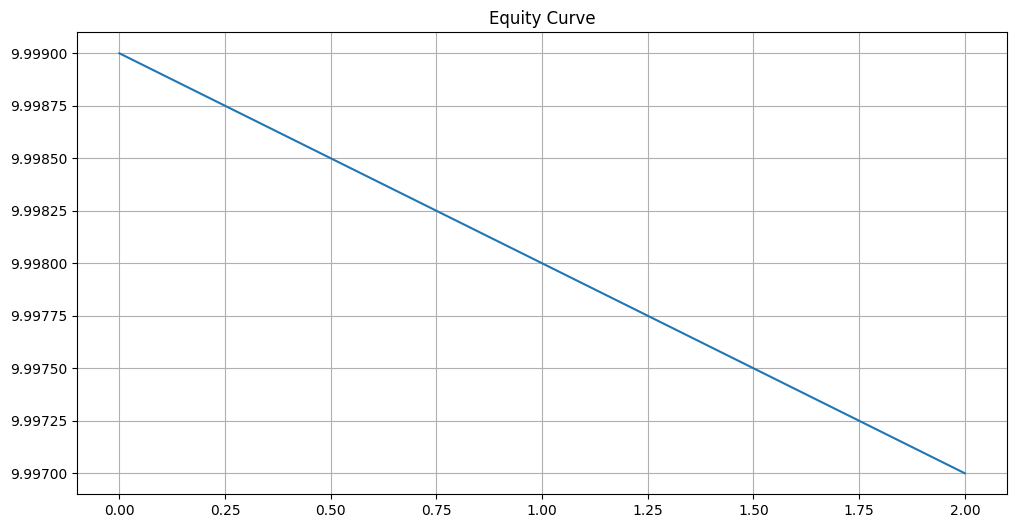

In [6]:
# Load and prepare data
processor = DataProcessor()
processed_data = processor.process_all_data()

if processed_data and 'H1' in processed_data and 'M5' in processed_data:
    # Generate signals
    signals = processor.analyze_trends(processed_data['H1'], processed_data['M5'])
    
    if signals is not None:
        # Execute trades
        trades_df = execute_trades(signals)
        
        # Calculate performance metrics
        if not trades_df.empty:
            print("\nTrading Performance:")
            print(f"Total Trades: {len(trades_df)}")
            print(f"Profitable Trades: {len(trades_df[trades_df['pnl'] > 0])}")
            print(f"Total Profit/Loss: ${trades_df['pnl'].sum():.2f}")
            print(f"Win Rate: {(len(trades_df[trades_df['pnl'] > 0]) / len(trades_df) * 100):.1f}%")
            print(f"Final Balance: ${trades_df['balance'].iloc[-1]:.2f}")
            
            # Plot equity curve
            plt.figure(figsize=(12, 6))
            trades_df['balance'].plot(title='Equity Curve')
            plt.grid(True)
            plt.show()
        else:
            print("No trades were executed")
else:
    print("No data available for processing")

## Trade Analysis

Analyze trade performance and risk metrics


Detailed Performance Metrics:
Win Rate: 0.0%
Profit Factor: 0.00
Average Win: $nan
Average Loss: $-0.00
Stop Loss Hits: 3 (100.0%)


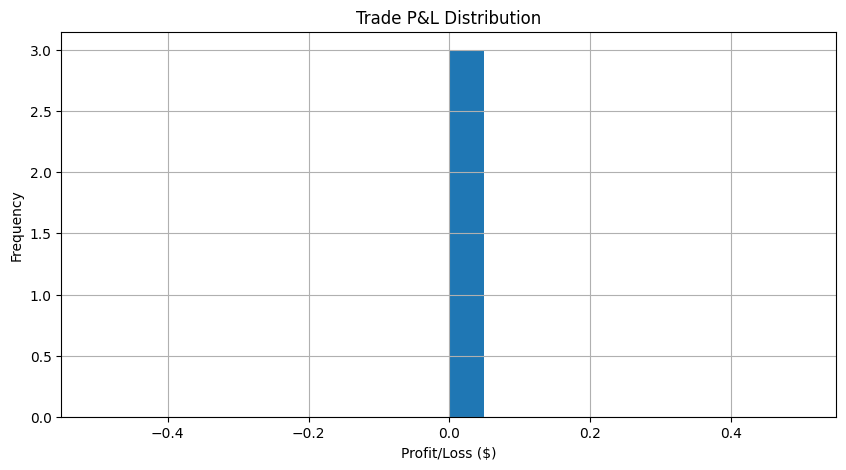

In [7]:
def analyze_trades(trades_df):
    """Calculate detailed trade performance metrics"""
    if trades_df.empty:
        return None
        
    metrics = {
        'total_trades': len(trades_df),
        'winning_trades': len(trades_df[trades_df['pnl'] > 0]),
        'losing_trades': len(trades_df[trades_df['pnl'] < 0]),
        'total_profit': trades_df[trades_df['pnl'] > 0]['pnl'].sum(),
        'total_loss': abs(trades_df[trades_df['pnl'] < 0]['pnl'].sum()),
        'max_win': trades_df['pnl'].max(),
        'max_loss': trades_df['pnl'].min(),
        'avg_win': trades_df[trades_df['pnl'] > 0]['pnl'].mean(),
        'avg_loss': trades_df[trades_df['pnl'] < 0]['pnl'].mean(),
        'stop_loss_hits': len(trades_df[trades_df['exit_reason'] == 'stop_loss'])
    }
    
    # Calculate win rate and risk metrics
    metrics['win_rate'] = (metrics['winning_trades'] / metrics['total_trades']) * 100
    metrics['profit_factor'] = metrics['total_profit'] / abs(metrics['total_loss']) if metrics['total_loss'] != 0 else float('inf')
    
    return metrics

if 'trades_df' in locals() and not trades_df.empty:
    metrics = analyze_trades(trades_df)
    if metrics:
        print("\nDetailed Performance Metrics:")
        print(f"Win Rate: {metrics['win_rate']:.1f}%")
        print(f"Profit Factor: {metrics['profit_factor']:.2f}")
        print(f"Average Win: ${metrics['avg_win']:.2f}")
        print(f"Average Loss: ${metrics['avg_loss']:.2f}")
        print(f"Stop Loss Hits: {metrics['stop_loss_hits']} ({metrics['stop_loss_hits']/metrics['total_trades']*100:.1f}%)")

        # Plot trade distribution
        plt.figure(figsize=(10, 5))
        trades_df['pnl'].hist(bins=20)
        plt.title('Trade P&L Distribution')
        plt.xlabel('Profit/Loss ($)')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()